# Costco (COST): Historical Financial Analysis, FY2020–FY2024

*Independent academic research and valuation case study; not investment advice.*

This notebook covers **Phase 2** of the project. It turns the source-tracked data from Phase 1 into the
analysis the forecast will rest on. Every input comes from Costco's 10-K filings, and each number links
to its tagged fact in `data/processed/financials_long.csv`. The metric definitions are in `src/historical.py`.

**Sections**
1. Data checks
2. Growth: what drove revenue
3. The profit engine: membership fees vs. merchandising
4. Margins and tax
5. Membership economics
6. Returns on capital and capital intensity
7. Working capital
8. Cash flow and capital allocation
9. Segments
10. What this means for the forecast

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, display
from src.historical import compute_metrics, cash_uses_5yr, incremental_roic, cagr, load
from src import charts

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
fin, ops = load()
m = compute_metrics()
charts.main()   # regenerate the chart pack from the same data
CH = ROOT / "outputs" / "charts"

def show(rows, fmt="{:.1%}"):
    return m.loc[rows].style.format(fmt, na_rep="–")

9 charts written to outputs/charts/


## 1. Data checks
The Phase 1 integrity tests must pass before any analysis runs. They check that the statements add up, tie to each other and to the segment totals, and match the SEC API.

In [2]:
import subprocess
r = subprocess.run([sys.executable, "-m", "pytest", "-q", "--color=no", "-p", "no:cacheprovider", str(ROOT / "tests")], capture_output=True, text=True, cwd=ROOT)
print(r.stdout.strip().splitlines()[-1])

30 passed in 1.43s


### Headline financials ($ millions)

In [3]:
rows = ["total_revenue", "net_sales", "membership_fees", "operating_income", "net_income", "cfo", "capex"]
t = fin.loc[rows, [2020, 2021, 2022, 2023, 2024]]
t.columns = [f"FY{c}" for c in t.columns]
t["CAGR FY20–24"] = [cagr(t.loc[r]) for r in rows]
t.style.format("{:,.0f}").format("{:.1%}", subset=["CAGR FY20–24"])

,FY2020,FY2021,FY2022,FY2023,FY2024,CAGR FY20–24
line_item,,,,,,
total_revenue,"166,761","195,929","226,954","242,290","254,453",11.1%
net_sales,"163,220","192,052","222,730","237,710","249,625",11.2%
membership_fees,"3,541","3,877","4,224","4,580","4,828",8.1%
operating_income,"5,435","6,708","7,793","8,114","9,285",14.3%
net_income,"4,002","5,007","5,844","6,292","7,367",16.5%
cfo,"8,861","8,958","7,392","11,068","11,339",6.4%
capex,"2,810","3,588","3,891","4,323","4,710",13.8%


## 2. Growth: what drove revenue

Revenue grew from **$166.8bn to $254.5bn**, an 11% compound annual rate. That rate overstates the run-rate:

* **FY2021–22 was a surge.** Pandemic stock-up, food inflation and high gasoline prices lifted comparable sales by 16% and 14%.
* **FY2023–24 was normal.** Comparable sales slowed to 3% and 5%. Excluding gasoline prices and FX they were 5% and 6%, which is the better measure of underlying volume and price.
* **FY2023 had 53 weeks.** Unadjusted, FY2023 growth looks better and FY2024 worse than they really were. On a 52-week basis net sales grew about 4.7% in FY2023 and 7.0% in FY2024.

New warehouses add a steady **~2 points** of growth a year. Costco opened 20–29 net new warehouses a year, lifting the count from 795 to 890 (unit growth of 2.5–3.4%).

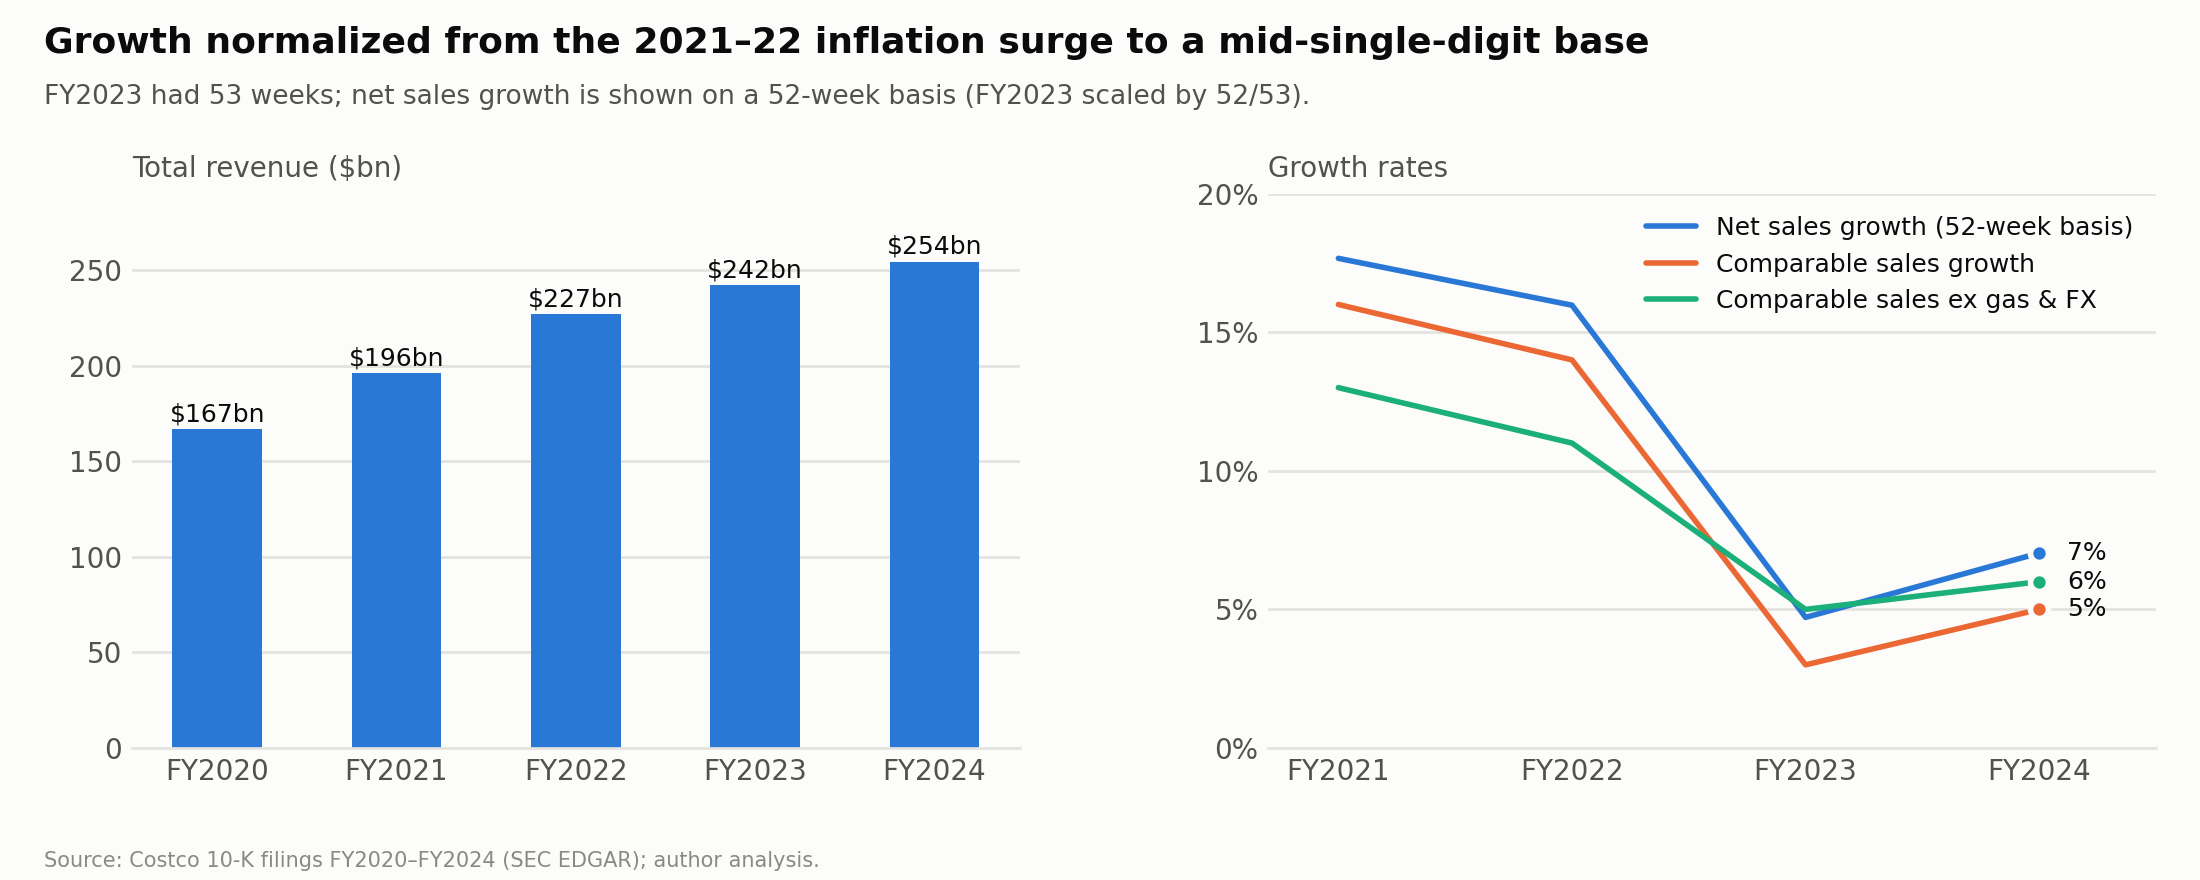

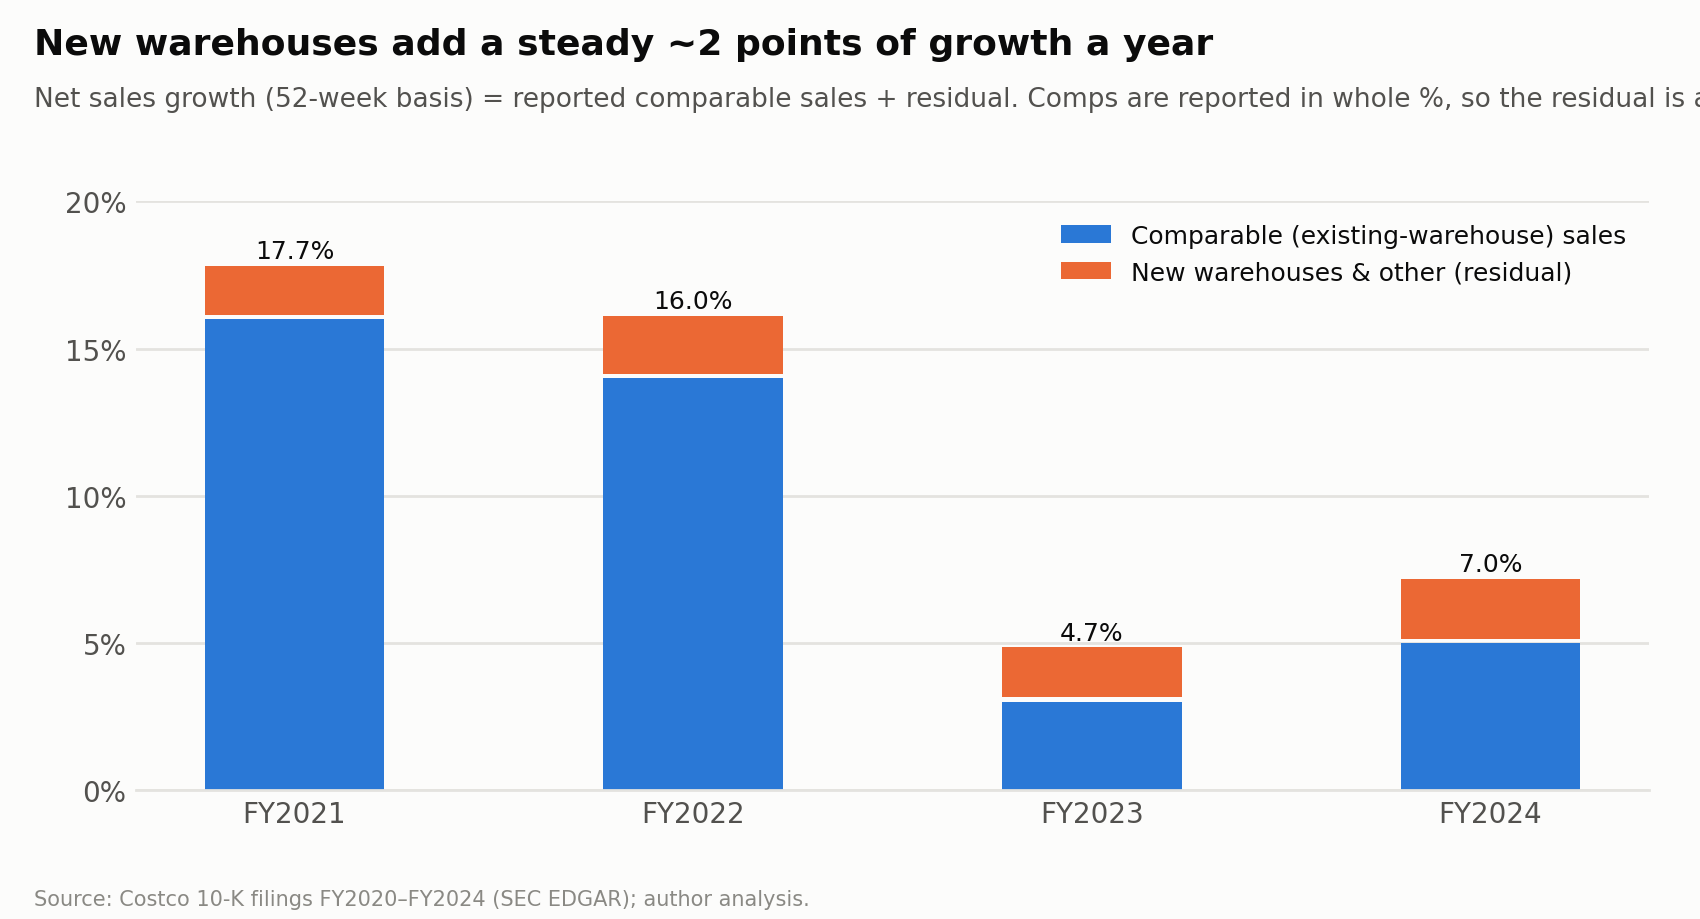

,FY2020,FY2021,FY2022,FY2023,FY2024
net_sales_growth,–,17.7%,16.0%,6.7%,5.0%
net_sales_growth_52wk,–,17.7%,16.0%,4.7%,7.0%
comparable_sales_growth,8.0%,16.0%,14.0%,3.0%,5.0%
comparable_sales_growth_ex_gas_fx,9.0%,13.0%,11.0%,5.0%,6.0%
non_comp_growth_52wk,–,1.7%,2.0%,1.7%,2.0%
warehouse_growth,–,2.5%,2.8%,2.7%,3.4%
floor_space_growth,–,2.4%,3.0%,3.1%,3.6%


In [4]:
display(Image(CH / "01_revenue_and_growth.png")); display(Image(CH / "02_growth_decomposition.png"))
show(["net_sales_growth", "net_sales_growth_52wk", "comparable_sales_growth", "comparable_sales_growth_ex_gas_fx",
      "non_comp_growth_52wk", "warehouse_growth", "floor_space_growth"])

In [5]:
m.loc[["warehouses", "net_new_warehouses", "net_sales_per_avg_warehouse", "net_sales_per_avg_sqft"]].style.format("{:,.0f}", na_rep="–")

,FY2020,FY2021,FY2022,FY2023,FY2024
warehouses,795,815,838,861,890
net_new_warehouses,–,20,23,23,29
net_sales_per_avg_warehouse,–,239,269,275,285
net_sales_per_avg_sqft,–,"1,634","1,845","1,875","1,941"


**Productivity.** Net sales per average warehouse rose from about $239m to $285m (52-week basis), and sales per square foot from about $1,634 to $1,941.
New warehouses start below the fleet average and ramp up over several years, so existing warehouses are the main source of productivity gains.

## 3. The profit engine: membership fees vs. merchandising

Costco prices merchandise close to cost and makes much of its profit from the annual fee.
Here, *merchandising profit* means operating income minus membership fees.

* **Membership fees** were **$4.8bn in FY2024: 1.9% of revenue, but 52% of operating income.** In FY2020 they were 65%.
* **Merchandising profit** more than doubled, from $1.9bn to $4.5bn. Its margin on net sales widened from 1.2% to 1.8%, as SG&A was spread over more sales.

Fee income is almost pure profit and recurs every year, with ~93% renewal in the U.S. and Canada. That makes Costco's earnings
steadier than its thin margins suggest, and the DCF should treat it that way.

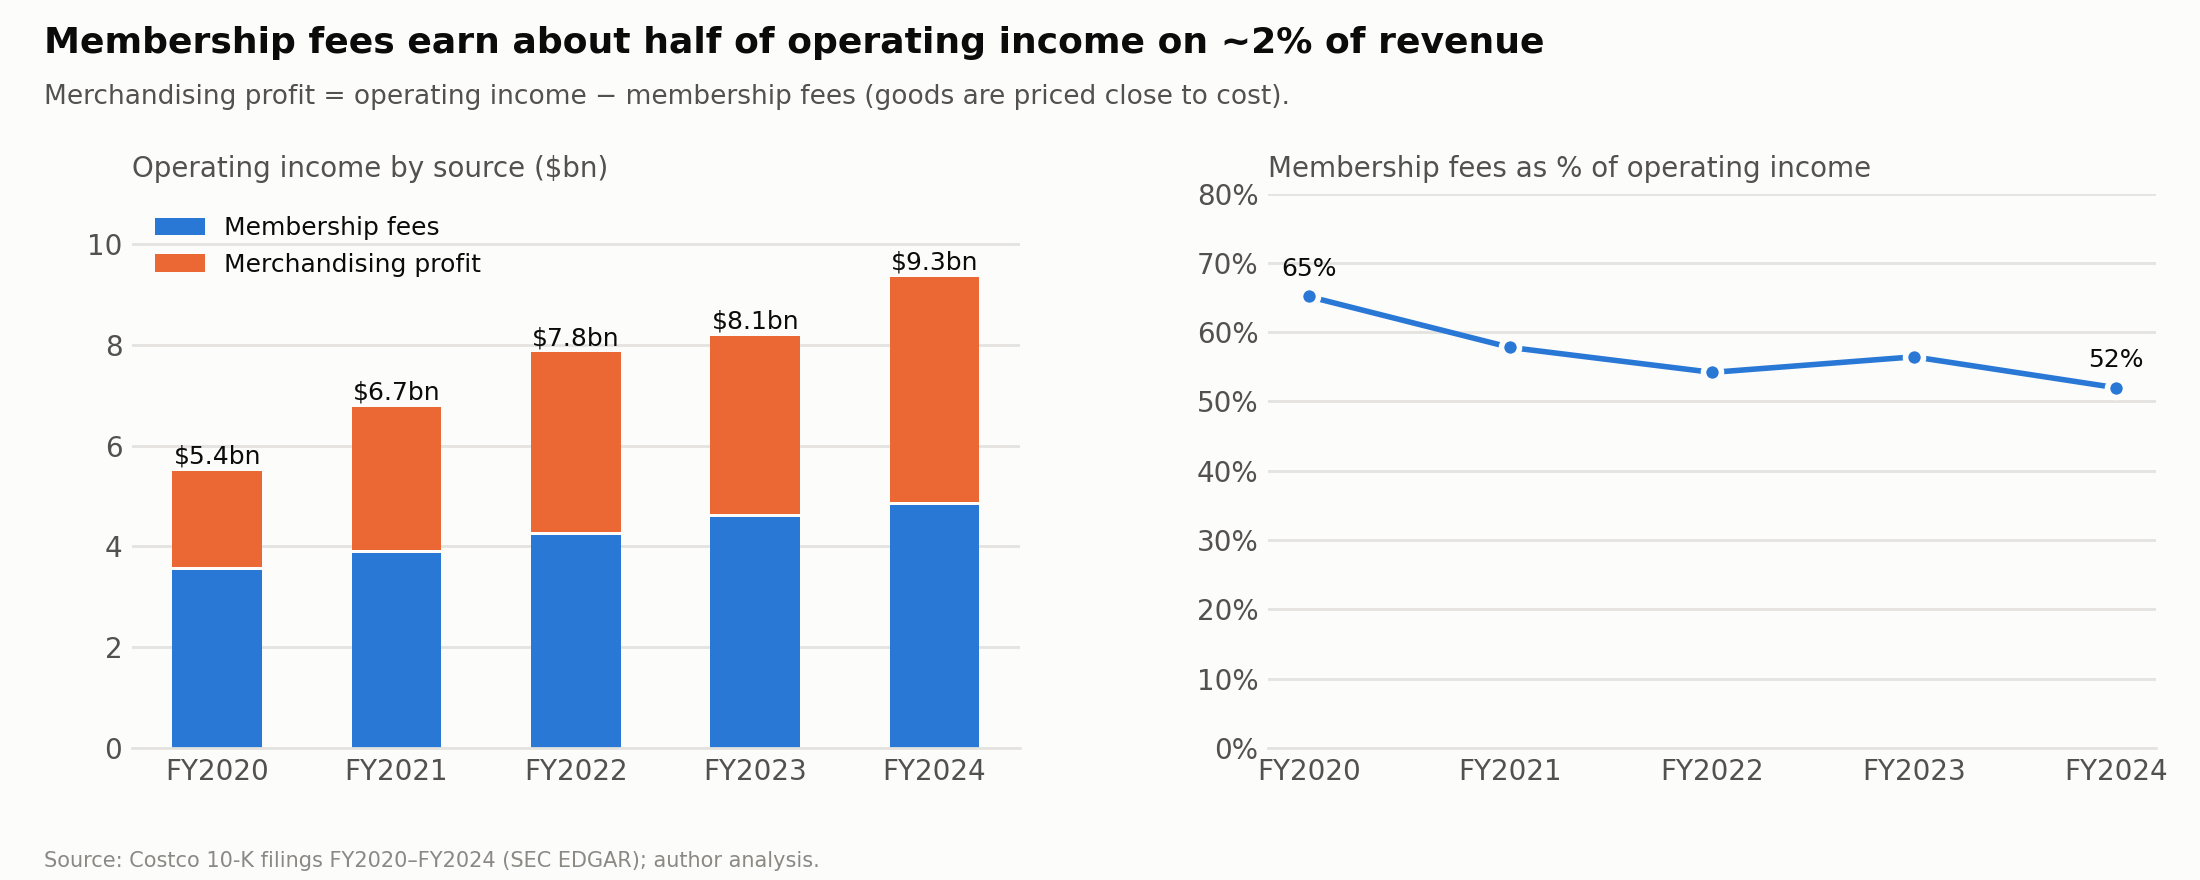

,FY2020,FY2021,FY2022,FY2023,FY2024
membership_fees_pct_revenue,2.1%,2.0%,1.9%,1.9%,1.9%
membership_fees_pct_operating_income,65.2%,57.8%,54.2%,56.4%,52.0%
merchandise_operating_margin,1.2%,1.5%,1.6%,1.5%,1.8%


In [6]:
display(Image(CH / "03_profit_engine.png"))
m.loc[["membership_fees_pct_revenue", "membership_fees_pct_operating_income", "merchandise_operating_margin"]].style.format("{:.1%}")

## 4. Margins and tax

* **Gross margin on net sales** held in a tight band of **10.5–11.2%**. It dipped in FY2022 because of a LIFO inventory charge and a higher gasoline mix; gasoline sells at a low margin percentage. It recovered to 10.9% by FY2024.
* **SG&A fell from 10.0% to 9.1% of net sales.** Fixed warehouse costs were spread over higher sales.
* **Operating margin rose from 3.3% to 3.65%**, the highest in the period.
* **Tax.** The reported effective rate was 24–26%, helped by one-off *discrete* benefits such as stock-compensation deductions and, in FY2024, the 401(k) portion of the special dividend.
  **Excluding these, the rate was 25.9–26.6% every year.** The forecast should use roughly 26%, not the reported 24.4%.

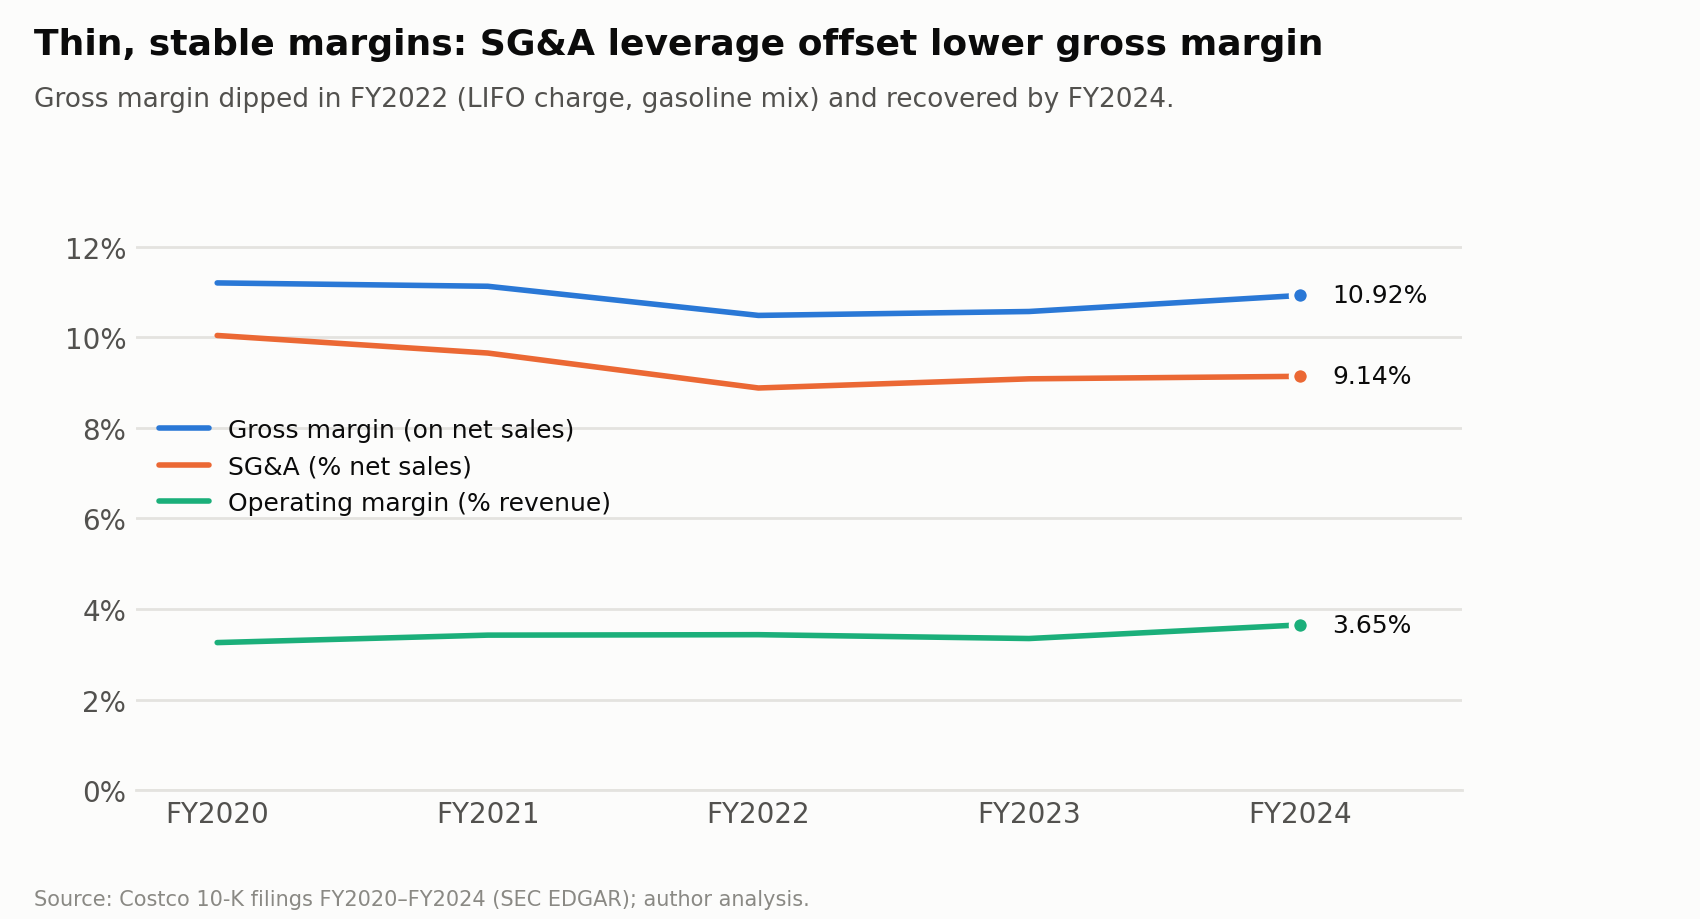

,FY2020,FY2021,FY2022,FY2023,FY2024
gross_margin_on_net_sales,11.20%,11.13%,10.48%,10.57%,10.92%
sga_pct_net_sales,10.04%,9.65%,8.88%,9.08%,9.14%
operating_margin,3.26%,3.42%,3.43%,3.35%,3.65%
net_margin,2.40%,2.56%,2.57%,2.60%,2.90%
effective_tax_rate,24.37%,23.97%,24.55%,25.86%,24.36%
effective_tax_rate_ex_discrete,25.90%,26.40%,26.20%,26.60%,26.44%


In [7]:
display(Image(CH / "04_margins.png"))
show(["gross_margin_on_net_sales", "sga_pct_net_sales", "operating_margin", "net_margin", "effective_tax_rate", "effective_tax_rate_ex_discrete"], "{:.2%}")

## 5. Membership economics

* **Paid members** grew from 58.1m to 76.2m, 7.0% a year. That is faster than warehouse growth, so each warehouse serves more members over time.
* **Executive members** rose from 39% to 46% of paid members. They pay twice the fee, earn a 2% reward, and generated 73% of worldwide net sales in FY2024.
* **Renewal rates** reached **92.9% in the U.S. and Canada and 90.5% worldwide.** FY2020–22 figures are rounded in the filings.
* **Fee income per average paid member** was flat at about $65–66 on a 52-week basis, because there was no fee increase in the period.
  The **$60 to $65 increase effective 1 Sep 2024** (Executive: $120 to $130) is therefore a clear FY2025–26 driver.
  Fees are recognized over the 12-month membership term, so the increase phases in as members renew.

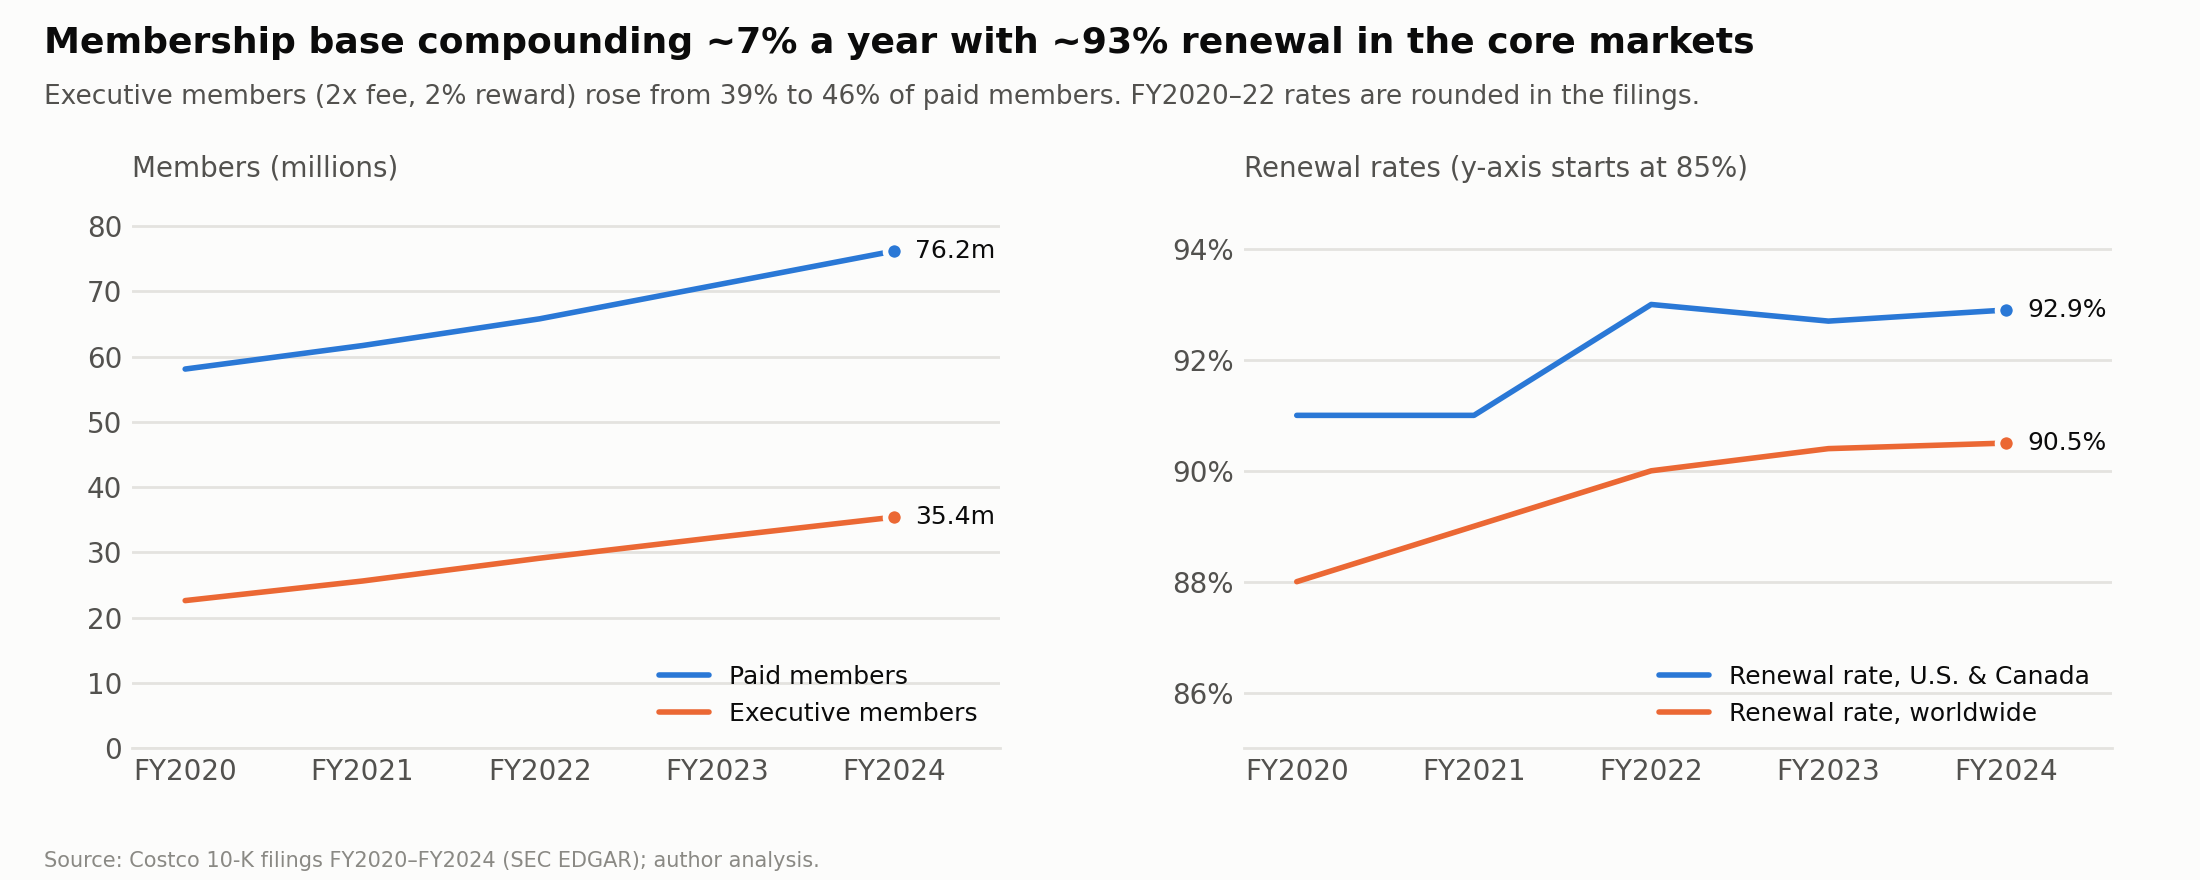

,FY2020,FY2021,FY2022,FY2023,FY2024
paid_members_m,58.100,61.700,65.800,71.000,76.200
paid_member_growth,NaN,0.062,0.066,0.079,0.073
executive_members_m,22.600,25.600,29.100,32.300,35.400
executive_share_of_paid,0.389,0.415,0.442,0.455,0.465
fee_per_avg_paid_member,NaN,64.725,66.259,65.696,65.598
renewal_rate_us_canada,0.910,0.910,0.930,0.927,0.929
renewal_rate_worldwide,0.880,0.890,0.900,0.904,0.905


In [8]:
display(Image(CH / "05_membership.png"))
m.loc[["paid_members_m", "paid_member_growth", "executive_members_m", "executive_share_of_paid",
       "fee_per_avg_paid_member", "renewal_rate_us_canada", "renewal_rate_worldwide"]]

## 6. Returns on capital and capital intensity

**Return on invested capital (ROIC) = NOPAT ÷ average invested capital.**
* NOPAT is operating income × (1 − effective tax rate).
* Invested capital is debt + lease liabilities + equity − cash − short-term investments.
* Leases are included because warehouses held on leases are operating assets.

* ROIC was **~30%** in FY2021–24. FY2020 is 25%, but that year is measured on year-end capital.
* **Incremental ROIC** is the extra NOPAT earned per extra dollar invested between FY2020 and FY2024. It is about 49%, so recent investment earned even more than the existing base.
* **Capex ran at 1.7–1.9% of revenue, about 2x depreciation.** The difference is growth investment: new warehouses, depots and relocations.
* **Revenue was ~9x net property and equipment.** That is very asset-light for a store-based retailer.

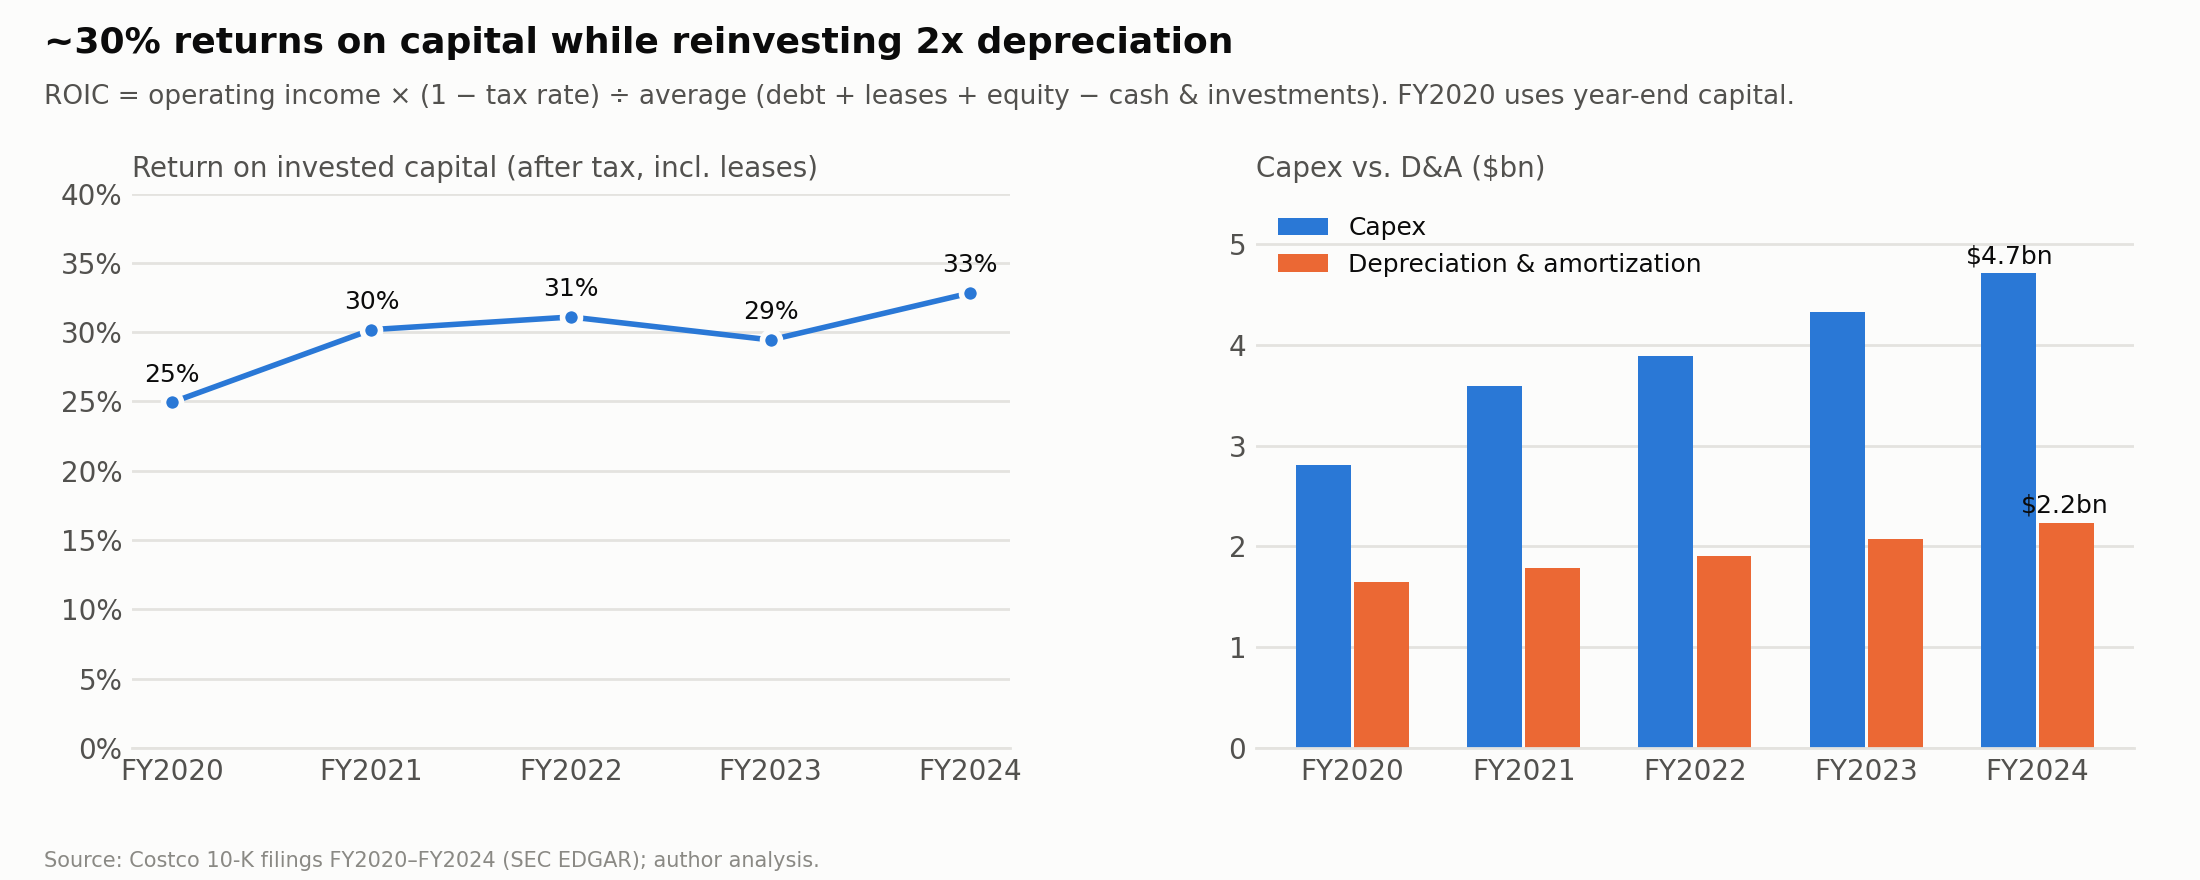

Incremental ROIC FY2020→FY2024: 49.0%


,FY2020,FY2021,FY2022,FY2023,FY2024
nopat,"4,110.428","5,100.289","5,879.540","6,015.469","7,022.854"
invested_capital,"16,486.000","17,310.000","20,504.000","20,360.000","22,427.000"
roic,0.249,0.302,0.311,0.294,0.328
roe,0.239,0.279,0.306,0.275,0.303
capex_pct_revenue,0.017,0.018,0.017,0.018,0.019
d_and_a_pct_revenue,0.010,0.009,0.008,0.009,0.009
capex_to_d_and_a,1.708,2.015,2.048,2.081,2.105
revenue_to_avg_ppe,7.811,8.650,9.429,9.440,9.134


In [9]:
display(Image(CH / "06_returns_and_capex.png"))
print(f"Incremental ROIC FY2020→FY2024: {incremental_roic(m):.1%}")
m.loc[["nopat", "invested_capital", "roic", "roe", "capex_pct_revenue", "d_and_a_pct_revenue", "capex_to_d_and_a", "revenue_to_avg_ppe"]]

## 7. Working capital

Costco turns over its inventory in about **29 days** and pays suppliers in about **30 days**.
Year-end accounts payable are about the same size as inventory (roughly 1.0–1.2x), so suppliers finance the inventory.

Operating working capital is also negative because of **deferred membership fees**: members pay upfront and Costco recognizes the fee over the year.
Excluding cash and debt, it was **−$12.3bn (−4.8% of revenue) in FY2024**.

**Why it matters for the DCF:** when working capital is negative, growth *releases* cash instead of consuming it.
FY2022 was the exception: inventory was built up during supply-chain disruption and inflation, and FCF conversion fell to 0.6x.

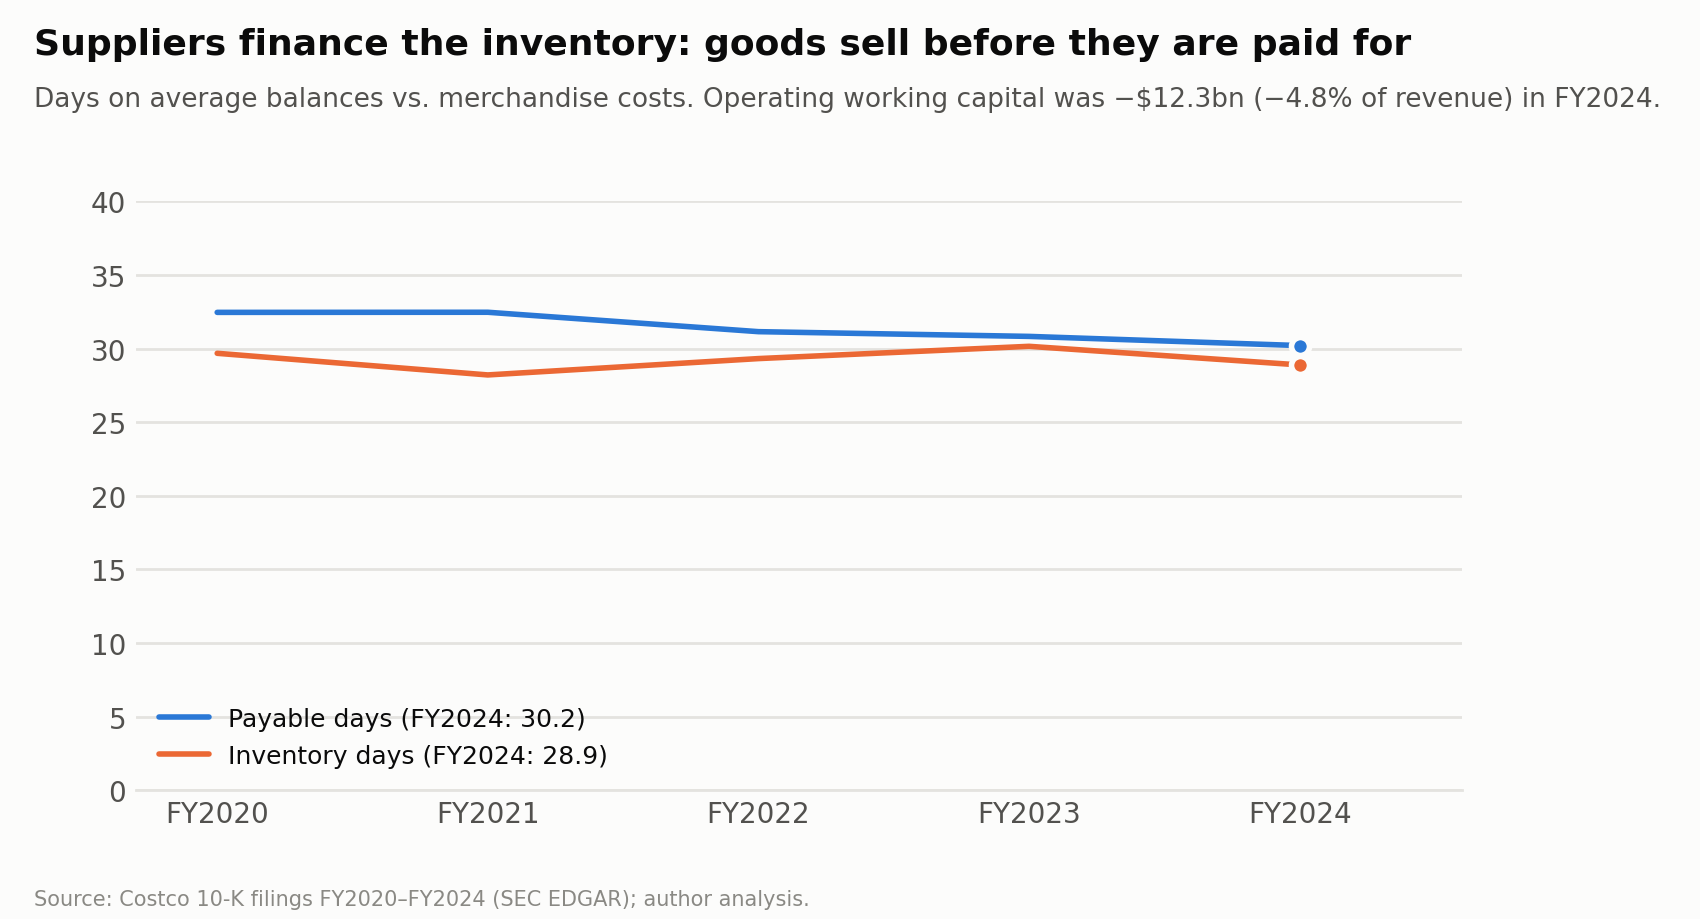

,FY2020,FY2021,FY2022,FY2023,FY2024
operating_nwc,"-9,934.000","-11,312.000","-10,278.000","-11,857.000","-12,259.000"
operating_nwc_pct_revenue,-0.060,-0.058,-0.045,-0.049,-0.048
change_in_operating_nwc,"-2,437.000","-1,378.000","1,034.000","-1,579.000",-402.000
inventory_days,29.681,28.211,29.322,30.155,28.891
payable_days,32.461,32.469,31.151,30.829,30.206
payables_to_inventory,1.158,1.145,0.997,1.050,1.042
deferred_fees_pct_fee_income,0.523,0.527,0.515,0.510,0.518


In [10]:
display(Image(CH / "07_working_capital.png"))
m.loc[["operating_nwc", "operating_nwc_pct_revenue", "change_in_operating_nwc", "inventory_days", "payable_days",
       "payables_to_inventory", "deferred_fees_pct_fee_income"]]

## 8. Cash flow and capital allocation

* **Free cash flow (FCF = operating cash flow − capex)** was $3.5–6.7bn a year. That is an FCF margin of about 2.6%, and 0.9–1.1x net income in normal years.
* **Where FY2020–24 operating cash went (cumulative $47.6bn):**
  * capex: 41%;
  * regular dividends: 17%;
  * special dividends: 23% ($10/share in Dec 2020 and $15/share in Jan 2024);
  * buybacks: just 5%.
* **Regular dividend payout** (declared per share, excluding specials, ÷ diluted EPS) held at **26–30%**.
* The share count barely moved, at about 444m diluted. Buybacks offset stock-compensation dilution but did not reduce the count.
* The balance sheet held **net cash of $5.2bn** at FY2024. After lease liabilities, it was roughly **$1.2bn** net cash.

**Pattern:** Costco builds up cash, then pays it out as special dividends. The DCF values *free cash flow*, so these
payouts do not affect enterprise value. They matter only for the net-cash position at the valuation date.

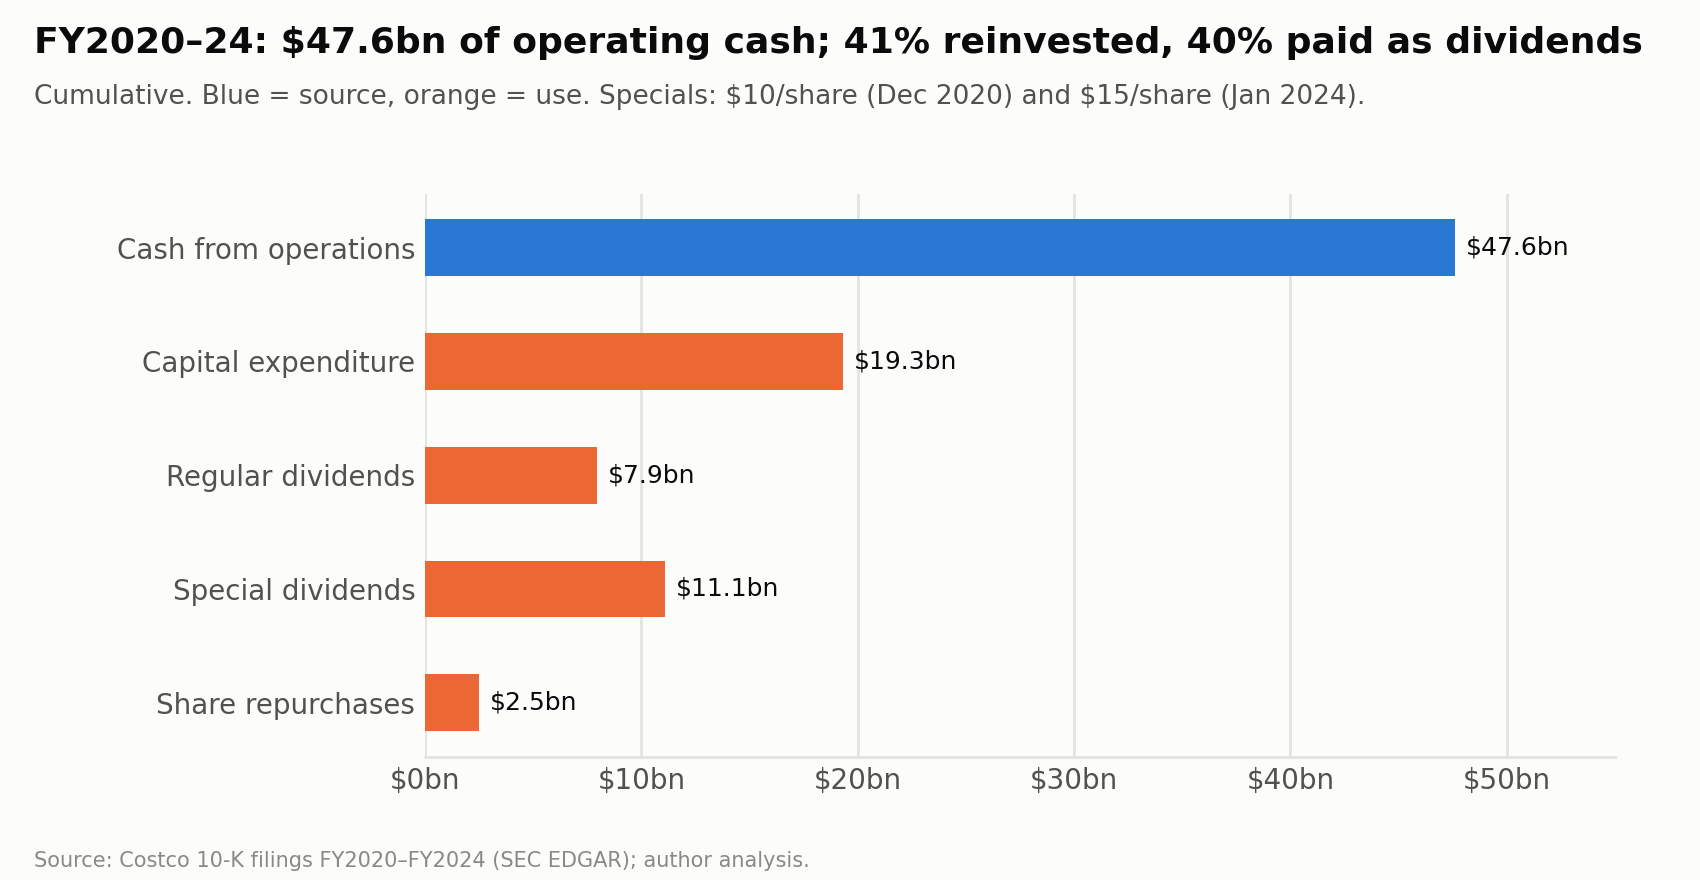

,FY2020-24 cumulative ($m),% of CFO
Cash from operations,"47,618",100.0%
Capital expenditure,"-19,322",-40.6%
Regular dividends,"-7,932",-16.7%
Special dividends,"-11,085",-23.3%
Share repurchases,"-2,507",-5.3%


,FY2020,FY2021,FY2022,FY2023,FY2024
free_cash_flow,"6,051.000","5,370.000","3,501.000","6,745.000","6,629.000"
fcf_margin,0.036,0.027,0.015,0.028,0.026
fcf_conversion,1.512,1.072,0.599,1.072,0.900
regular_dps_declared,2.700,2.980,3.380,3.840,4.360
regular_payout_ratio,0.299,0.264,0.257,0.271,0.263
special_dividends,0.000,"4,430.000",0.000,0.000,"6,655.000"
buybacks,196.000,496.000,439.000,676.000,700.000
net_cash,"5,696.000","4,684.000","4,492.000","8,776.000","5,247.000"
net_cash_after_leases,"2,219.000",768.000,143.000,"4,698.000","1,195.000"
diluted_shares_m,443.901,444.346,444.757,444.452,444.759


In [11]:
display(Image(CH / "08_cash_uses.png"))
display(cash_uses_5yr().style.format({"FY2020-24 cumulative ($m)": "{:,.0f}", "% of CFO": "{:.1%}"}))
m.loc[["free_cash_flow", "fcf_margin", "fcf_conversion", "regular_dps_declared", "regular_payout_ratio",
       "special_dividends", "buybacks", "net_cash", "net_cash_after_leases", "diluted_shares_m"]]

## 9. Segments

The U.S. is **72% of revenue**, but it has the lowest segment margin, 3.4% in FY2024.
Canada earns 4.7% and Other International 4.0%. Mix is roughly stable, so segment shifts are not a major valuation driver.
The forecast is therefore built on consolidated drivers, with segment data used as a cross-check.

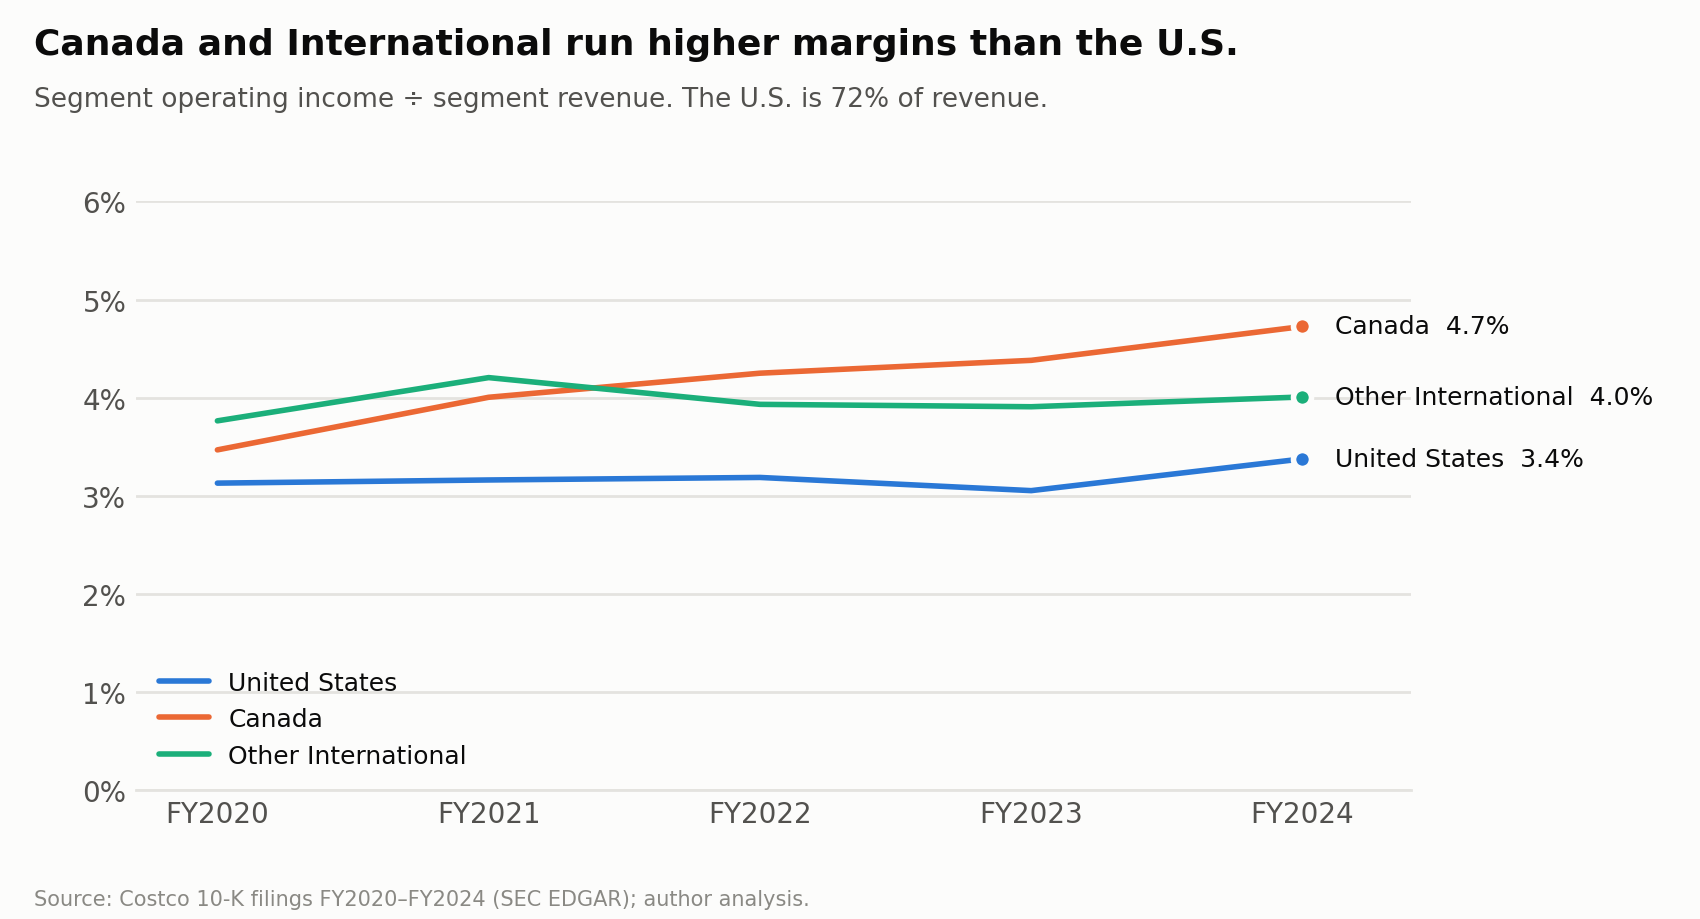

,FY2020,FY2021,FY2022,FY2023,FY2024
segment_revenue_share_us,73.2%,72.2%,72.8%,72.9%,72.4%
segment_revenue_share_canada,13.5%,13.9%,14.0%,13.6%,13.7%
segment_revenue_share_other_intl,13.3%,13.9%,13.2%,13.5%,13.9%
segment_margin_us,3.1%,3.2%,3.2%,3.1%,3.4%
segment_margin_canada,3.5%,4.0%,4.2%,4.4%,4.7%
segment_margin_other_intl,3.8%,4.2%,3.9%,3.9%,4.0%


In [12]:
display(Image(CH / "09_segment_margins.png"))
show(["segment_revenue_share_us", "segment_revenue_share_canada", "segment_revenue_share_other_intl",
      "segment_margin_us", "segment_margin_canada", "segment_margin_other_intl"])

## 10. What this means for the Phase 3 forecast

| Driver | FY2020–24 evidence | Starting point for the forecast (to be set in Phase 3) |
|---|---|---|
| Warehouse growth | 20–29 net openings/yr; 2.5–3.4% unit growth | Tie to announced opening plans; ~3% unit growth |
| Comparable sales | 5–6% ex gas & FX in the normalized years (FY23–24) | Mid-single-digit, fading toward nominal GDP plus share gains |
| Membership fees | ~7% member growth; fee per member flat; 2024 fee increase | Member growth + Executive mix + phased $5/$10 fee increase in FY25–26 |
| Gross margin | 10.5–11.2% band | Hold near FY2024 level; no margin expansion story |
| SG&A | Leverage from 10.0% to 9.1% of net sales | Modest further leverage at best; wage investment is a risk |
| Tax rate | 25.9–26.6% excluding discrete items | ~26% |
| Capex | 1.7–1.9% of revenue; ~2x D&A | ~1.8–2.0% of revenue while growing; converge toward D&A in terminal year |
| Working capital | −4.8% of revenue | Hold at about −5% of revenue, so growth releases cash |
| ROIC | ~30%; incremental ~49% | Terminal value must be consistent with high but fading returns |

*Every assumption will be written down with its reasoning in `docs/assumptions.md` in Phase 3.*